# Detiding Seafloor Pressure Data
This notebook goes over the process for detiding pressure data from ONC's sensor at Folger Deep. This sensor is close to BMSC, at around 100 m depth. ONC also operates an observatory at Folger Pinnacle, at the top of the seamount next to Folger Deep.

![A map of the Folger Passage observatory showing the location of Folger Deep](https://farm66.staticflickr.com/65535/14503995881_3d3d1e5942_z.jpg)

## 1.1 Setup and Initialization
First, let's import the necessary libraries and initialize the ONC API client. A token is needed to use ONC's API. If the environment variable ONC_TOKEN is defined, that token will be used. Otherwise, you can provide your own token.

In [1]:
from onc import ONC
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch
import scipy.io as sio
import os
import datetime
import glob

token = os.environ.get("ONC_TOKEN")
if not token:
    # fill in your own token if not using an environment variable
    onc = ONC(token ='ab9739e4-c537-42d7-99b1-219909b915b3', outPath="./output")
else:
    onc = ONC(token, outPath="./output")

## 1.2 Fetching the CTD Pressure Data
We'll use getScalardataByDevice to request 10 days of pressure data from the Folger Deep CTD. This is the easiest ONC pressure data to access, and CTDs are deployed at every observatory. Once our data is returned, we'll store it in a DataFrame.

You can read more about the format of the request and response, as well as trying out sending and receiving information from the API, here: https://data.oceannetworks.ca/OpenAPI#get-/scalardata/location

In [2]:
# Define our device and timeframe
start_date = '2023-01-01T00:00:00.000Z'
end_date = '2023-01-10T00:00:00.000Z'

# Fetch the raw scalar data
raw_data_response = onc.getScalardataByLocation({
    'locationCode': 'FGPD',
    'deviceCategoryCode': 'CTD',
    'propertyCode': 'pressure',
    'dateFrom': start_date,
    'dateTo': end_date,
    'resamplePeriod': 15  # seconds: one sample every 15 s
})

# Parse the response into a Pandas DataFrame
sensor_data = raw_data_response['sensorData'][0]
times = pd.to_datetime(sensor_data['data']['sampleTimes'])
raw_pressure = np.array(sensor_data['data']['values'])

df = pd.DataFrame({'time': times, 'raw pressure': raw_pressure})
df.set_index('time', inplace=True)
display(df.head())

,raw pressure
time,
2023-01-01 00:00:07.500000+00:00,96.419000
2023-01-01 00:00:22.500000+00:00,96.405667
2023-01-01 00:00:37.500000+00:00,96.415786
2023-01-01 00:00:52.500000+00:00,96.405333
2023-01-01 00:01:07.500000+00:00,96.393133


## 1.3 Butterworth filtering to remove tides
First, we'll try a naive Butterworth filter to remove the tides. We'll create two new DataFrame columns: one column of highpass filtered data with the tides removed, and one of lowpass filtered data with just the tides. We set our cutoff period to 4 hours in order to remove both the 12 hour and 24 hour tides.

The filtering methods we're using come from the SciPy Signal library. Butterworth filters are used in signal processing for their smooth frequency response, which comes at the cost of a less steep cutoff.

In [3]:
# Measure the sampling interval from the data
sample_interval = pd.Series(df.index).diff().median()
print(f"sample interval: {sample_interval}")

# Sampling frequency, in samples per minute
fs = 1 / (sample_interval.total_seconds() / 60)

# Cutoff period: 4 hours (in minutes)
cutoff_period_minutes = 4 * 60 
cutoff_freq = 1 / cutoff_period_minutes

# Create a high-pass Butterworth filter
b, a = butter(N=4, Wn=cutoff_freq, btype='high', fs=fs)

# Apply the filter forward and backward (filtfilt) to prevent phase shifting
df['highpass filtered'] = filtfilt(b, a, df['raw pressure'])

sample interval: 0 days 00:00:15


In [4]:
# Create a low-pass Butterworth filter
b, a = butter(N=4, Wn=cutoff_freq, btype='low', fs=fs)

# Apply the filter forward and backward (filtfilt) to prevent phase shifting
df['lowpass filtered'] = filtfilt(b, a, df['raw pressure'])

## 1.4 Visualizing and Comparing the Signals
Let's graph our raw data alongside our detided data. We create three plots: the raw CTD pressure, the lowpass filtered data containing just the tides, and the detided highpass filtered data.

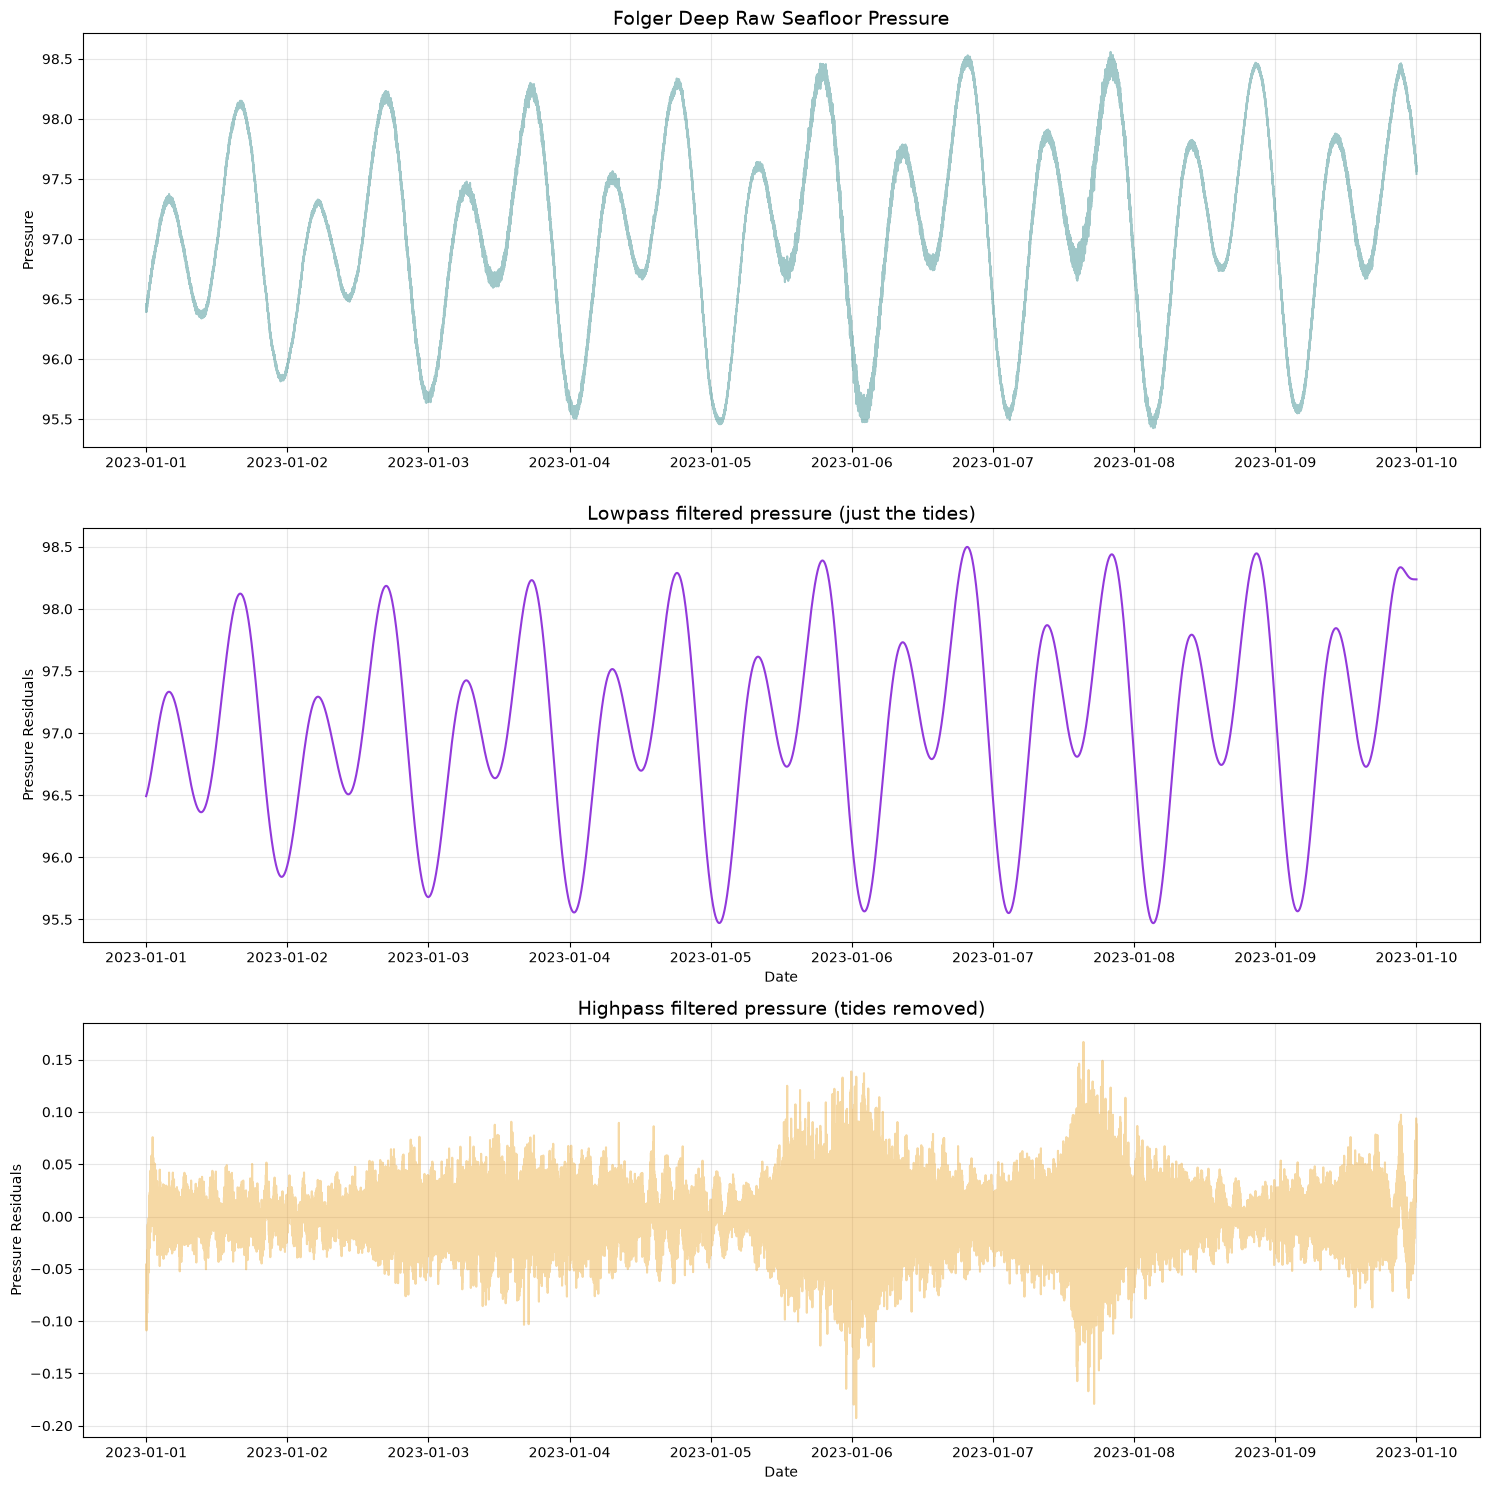

In [5]:
plt.figure(figsize=(15, 15))

plt.subplot(3, 1, 1)
plt.plot(df.index, df['raw pressure'], color='#16797c68', label='Raw CTD Pressure')
plt.title('Folger Deep Raw Seafloor Pressure', fontsize=14)
plt.ylabel('Pressure')
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 2)
plt.plot(df.index, df['lowpass filtered'], color='#9239DBFF', label='Lowpass filter tides')
plt.title('Lowpass filtered pressure (just the tides)', fontsize=14)
plt.ylabel('Pressure Residuals')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.subplot(3, 1, 3)
plt.plot(df.index, df['highpass filtered'], color='#eba22468', label='Highpass filter detided')
plt.title('Highpass filtered pressure (tides removed)', fontsize=14)
plt.ylabel('Pressure Residuals')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

That seems to have worked alright: we've definitely removed the giant tidal signal! Our highpass filtered data is much smaller in magnitude, and probably mostly contains surface waves. The bulges are probably storms (this data is from January).

## 2.1 Comparing with ONC detided pressure residuals
Next we'd like to compare with ONC's official detided data from the same location. ONC operated very sensitive Bottom pressure Recorders, and offers a Thomson Detided Time Series Scalar Data product, which is detided using the T_Tide toolbox implemented by R. Pawlowicz et al. This algorithm automatically uses 3 months of time series pressure data from around the time period requested, extracts the harmonics of the tides, and runs a Kaiser-Bessel filter.

For more information, see:
https://wiki.oceannetworks.ca/spaces/DP/pages/51086548/123
R. Pawlowicz, B. Beardsley, and S. Lentz, "Classical tidal harmonic analysis including error estimates in MATLAB using T_TIDE", Computers and Geosciences 28 (2002), 929-937.

Let's find out if this more sophisticated filter tracks the tides better!

In [6]:
params = {
    "dateFrom": start_date,
    "dateTo": end_date,
    "dataProductCode": "TSSTD",
    "locationCode": "FGPD",
    "deviceCategoryCode": "BPR",
    "propertyCode": "totalpressure",
    "extension": "mat",
    "dpo_qualityControl": "1",
    "dpo_dataGaps": "1",
    "dpo_resample": "15",
    "dpo_tsunamiKBfilter1": "0",
    "dpo_tsunamiKBfilter2": "0",
}
request = onc.orderDataProduct(params, includeMetadataFile=False)

Request Id: 49434334
Estimated File Size: No estimated file size available.
Estimated Processing Time: No estimated processing time available.
To cancel the running data product, run 'onc.cancelDataProduct(49434334)'


   Running
   Running... getting data for time segment 1 of 9....
   Running... getting data for time segment 3 of 9..
   Running... getting data for time segment 5 of 9...
   Running... getting data for time segment 8 of 9...
   Running... writing data products, time range 9 of 9.
   Search complete, waiting on the file system to synchronize (FolgerPassage_FolgerDeep_BottomPressureRecorder_SeafloorPressure_20230101T000000Z_20230110T000000Z-clean_avg50p15second_ThomsonDetided.mat)..............
   Skipping "FolgerPassage_FolgerDeep_BottomPressureRecorder_SeafloorPressure_20230101T000000Z_20230110T000000Z-clean_avg50p15second_ThomsonDetided.mat": File already exists.

Total run time: a moment
Total download Time: 0.000 seconds
1 files (0 Bytes) downloaded


## 2.2 Read the result

In the MAT file, `data.dat` is already the de-tided series (`sensorName` is
`Thomson Pressure Residual`, decibar). The fitted tide is under
`data.TidePrediction.dat`, so the raw observed anomaly is the sum of the two.
`data.time` is a MATLAB datenum.

In [7]:
def detided_product_file(date_from, date_to):
    """Find the downloaded ThomsonDetided .mat covering one requested time range.

    Section 5 orders a second, longer product into the same folder, so match on
    the timestamps ONC writes into the filename instead of taking whichever file
    glob happens to list first.
    """
    stamp = lambda iso: iso[:19].replace("-", "").replace(":", "") + "Z"
    pattern = f"output/*{stamp(date_from)}_{stamp(date_to)}*ThomsonDetided.mat"
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"no downloaded data product matching {pattern}")
    return matches[0]


mat = sio.loadmat(
    detided_product_file(start_date, end_date),
    squeeze_me=True,
    struct_as_record=False,
)
d = mat["data"]
tide_struct = np.atleast_1d(d.TidePrediction)[0]


def datenum_to_datetime(x):
    return (
        datetime.datetime.fromordinal(int(x))
        + datetime.timedelta(days=x % 1)
        - datetime.timedelta(days=366)
    )


time = np.array([datenum_to_datetime(x) for x in np.asarray(d.time, dtype=float)])
df['residual'] = np.asarray(d.dat, dtype=float)
df['calculated tide'] = np.asarray(tide_struct.dat, dtype=float)

print(d.sensorName, "|", d.units, "|", d.resampleDescription)
print(d.dataProductOptions)
print(f"{df['residual'].size} samples, residual std {df['residual'].std():.4f} dbar")

Thomson Pressure Residual | decibar | Fixed window averaging with 50% overlap
Average Overlap Fraction: 0.5. Kaiser-Bessel Filter Window Duration Step One: 0. Kaiser-Bessel Filter Window Duration Step Two: 0.
51840 samples, residual std 0.0616 dbar


## 2.3 Display the detided data
Let's graph the raw pressure from the BPR compared to the tides calculated by the T_Tide method, as well as the actual detided residuals.

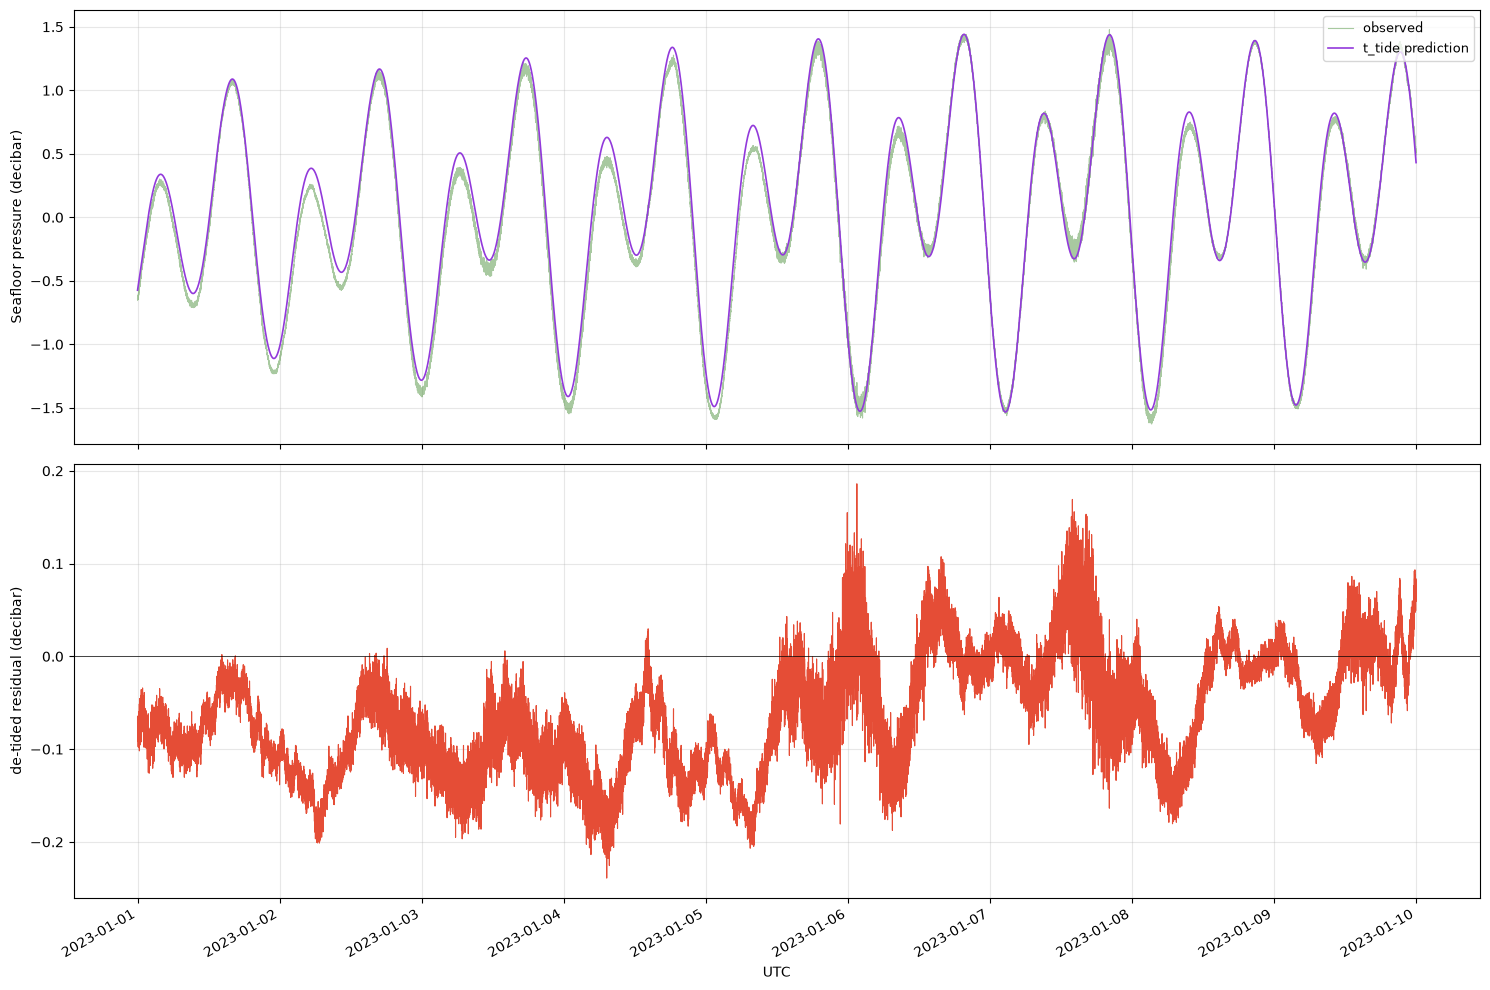

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
ax[0].plot(time, df['calculated tide'] + df['residual'], lw=0.8, color="#2a7c1668", label="observed")
ax[0].plot(time, df['calculated tide'], lw=1.2, color="#9239DBFF", label="t_tide prediction")
ax[0].set_ylabel(f"Seafloor pressure ({d.units})")
ax[0].legend(loc="upper right", fontsize=9)

ax[1].plot(time, df['residual'], lw=0.8, color="#E54D36FF")
ax[1].axhline(0, color="k", lw=0.5)
ax[1].set_ylabel(f"de-tided residual ({d.units})")
ax[1].set_xlabel("UTC")
for a in ax:
    a.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()

This also seems to have worked reasonably well. The predicted tide matches the actual tide quite closely, and the detided time series has retained more low-frequency components than our highpass Butterworth filter. However, the data retains a noticeable (though much weaker) daily component, so it seems like the tide might not have been completely eliminated.

## 3.1 Detiding with a daily average
For our third detiding method, we're going to go a different diffection: more simple. A basic daily average should remove the tidal component from the signal.

There are two ways to take the average:
- a **calendar-day block average**, one number per day, which is what `resample('1D').mean()` gives us
- a **centered running average** over one lunar day, which keeps the original 15 second resolution but costs us half a window (about 12 hours) of data at each end of the record

We'll try both forms of daily average.

In [9]:
# One lunar day is 24 h 50 min. Convert that to a number of samples using
# the sampling interval measured in section 1.3.
lunar_day = pd.Timedelta(hours=24, minutes=50)
samples_per_lunar_day = int(round(lunar_day / sample_interval))

# Calendar-day block average: one value per day, held constant across that day
daily_blocks = df['raw pressure'].resample('1D').mean()
df['daily average'] = daily_blocks.reindex(df.index, method='ffill')

# Centered running average over one lunar day: keeps the full sampling resolution
df['running daily average'] = (
    df['raw pressure'].rolling(samples_per_lunar_day, center=True).mean()
)

# The average is the detided signal, and the tide is what the average removed
df['daily average detided'] = df['running daily average'] - df['raw pressure'].mean()
df['daily average tide'] = df['raw pressure'] - df['running daily average']

print(f"averaging window: {samples_per_lunar_day} samples = {samples_per_lunar_day * sample_interval}")
print(f"raw pressure std      {df['raw pressure'].std():.4f} dbar")
print(f"detided std           {df['daily average detided'].std():.4f} dbar")
print(f"samples lost at the ends of the record: {int(df['running daily average'].isna().sum())}")


averaging window: 5960 samples = 1 days 00:50:00
raw pressure std      0.7813 dbar
detided std           0.0814 dbar
samples lost at the ends of the record: 5959


## 3.2 Display the daily averaged data
The top panel shows both averages drawn over the raw CTD pressure, and the bottom panel shows the detided signal each one produces.

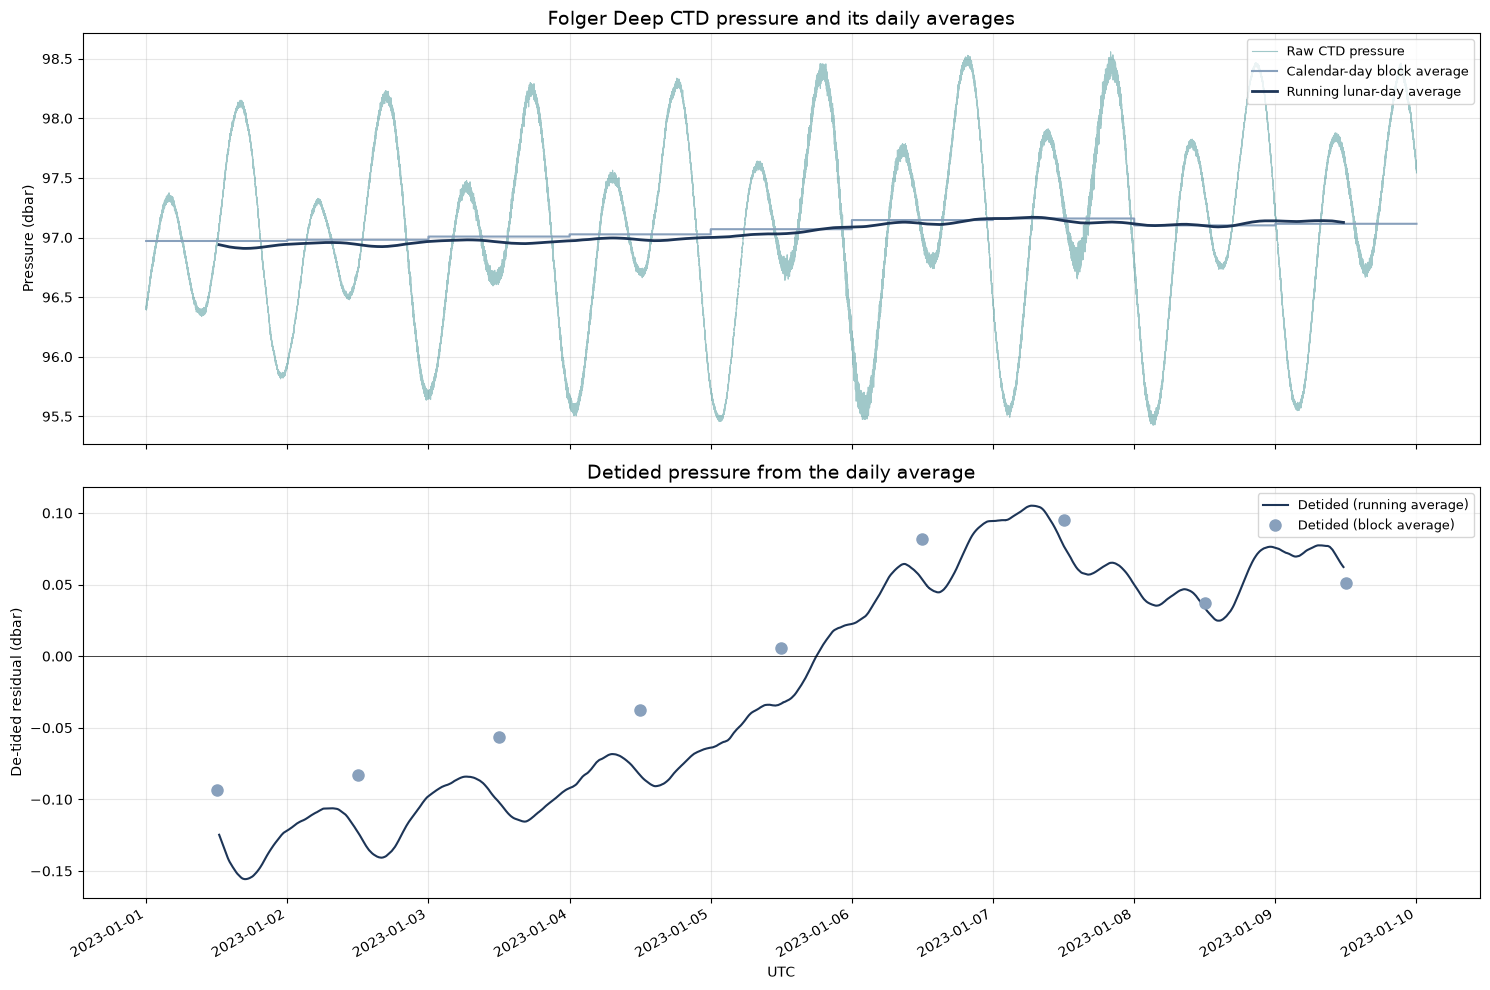

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

ax[0].plot(df.index, df['raw pressure'], lw=0.8, color="#16797c68", label="Raw CTD pressure")
ax[0].plot(df.index, df['daily average'], lw=1.5, color="#88A0BC",
           drawstyle="steps-post", label="Calendar-day block average")
ax[0].plot(df.index, df['running daily average'], lw=2, color="#1D3557",
           label="Running lunar-day average")
ax[0].set_title('Folger Deep CTD pressure and its daily averages', fontsize=14)
ax[0].set_ylabel("Pressure (dbar)")
ax[0].legend(loc="upper right", fontsize=9)

ax[1].plot(df.index, df['daily average detided'], lw=1.5, color="#1D3557",
           label="Detided (running average)")
ax[1].plot(daily_blocks.index + pd.Timedelta('12h'),
           daily_blocks - df['raw pressure'].mean(),
           'o', ms=8, color="#88A0BC", label="Detided (block average)")
ax[1].axhline(0, color="k", lw=0.5)
ax[1].set_title('Detided pressure from the daily average', fontsize=14)
ax[1].set_ylabel("De-tided residual (dbar)")
ax[1].set_xlabel("UTC")
ax[1].legend(loc="upper right", fontsize=9)

for a in ax:
    a.grid(alpha=0.3)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

This has removed the bulk of the tidal signal, but there's still a clear drift because the time periods we're averaging over don't precisely match the period of the tide. There are many tidal components, with periods of close to but not exactly 12 and 24 hours. Here's a few of the major ones:
| Component | Period (hours) |
|----|----|
|M2|12.4|
|S2|12|
|N2|12.7|
|K1|23.9|

Another obvious issue with this method is that it smoothes away all the high frequency components, which gets rid of all the surface waves, storms, or tsunamis in the data. Depending on the application, this might not be an issue.

## 4.1 Putting it together: Comparing the detiding methods
Below, we graph all three methods against each other: our Butterworth filter, the daily average, and ONC's T_Tide detided data. The middle panel compares the three estimates of the tide, and the bottom panel compares what each method leaves behind once the tide is removed. The tide estimates are all in decibars and centred on zero, so they share one axis.

Note the vertical scales on the graphs: all of our detided data has significantly smaller fluctuations than the original tides.

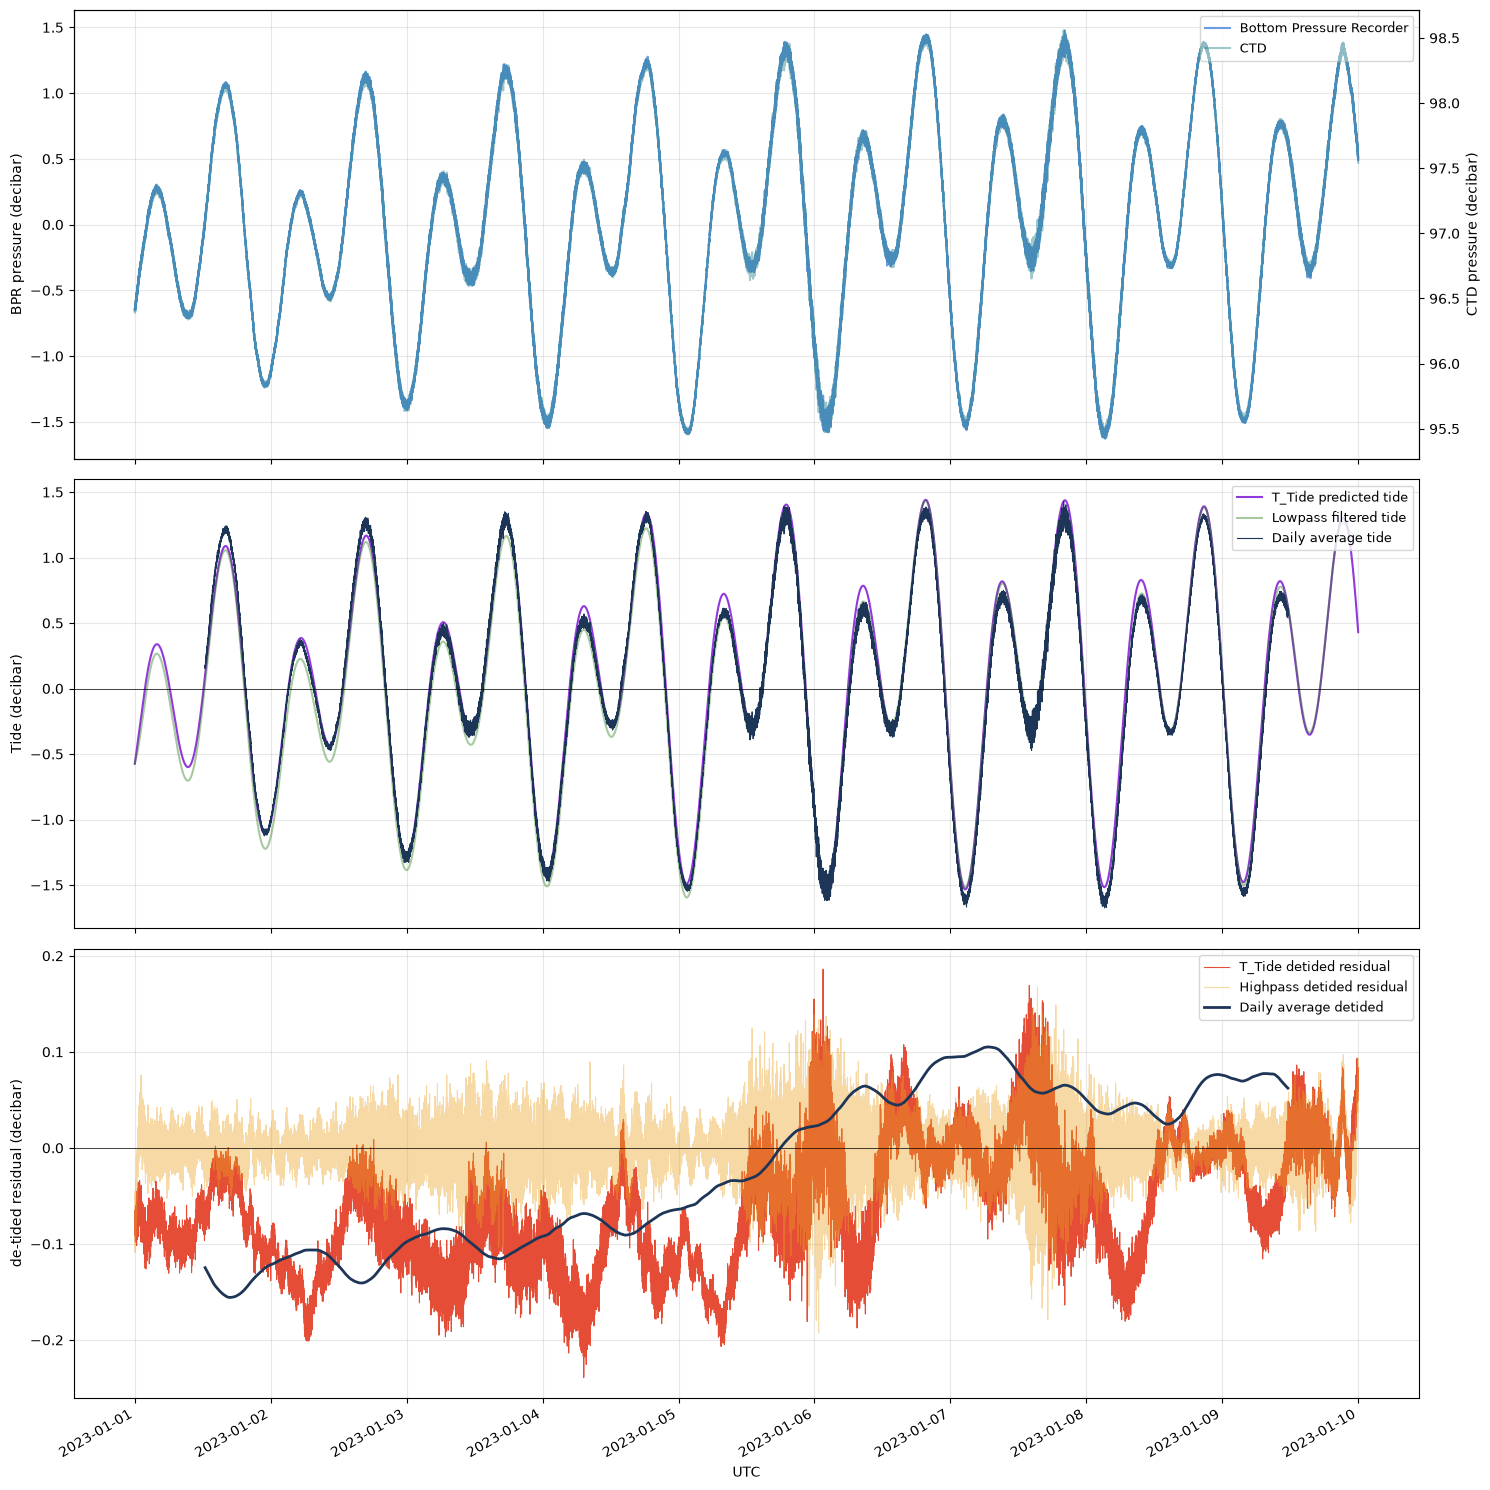

In [11]:
fig, ax = plt.subplots(3, 1, figsize=(15, 15), sharex=True)

line1 = ax[0].plot(time, df['calculated tide'] + df['residual'], color="#397ADBBF", label="Bottom Pressure Recorder")
ax[0].set_ylabel(f"BPR pressure ({d.units})")
raw_twin = ax[0].twinx()
line2 = raw_twin.plot(time, df['raw pressure'], color="#16797c68", label="CTD")
raw_twin.set_ylabel(f"CTD pressure ({d.units})")
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax[0].legend(lines, labels, loc="upper right", fontsize=9)

ax[1].plot(time, df['calculated tide'], color="#9239DBFF", label="T_Tide predicted tide")
ax[1].plot(time, df['lowpass filtered'] - df['lowpass filtered'].mean(),
           color="#2a7c1668", label="Lowpass filtered tide")
ax[1].plot(time, df['daily average tide'], lw=0.8, color="#1D3557",
           label="Daily average tide")
ax[1].axhline(0, color="k", lw=0.5)
ax[1].set_ylabel(f"Tide ({d.units})")
ax[1].legend(loc="upper right", fontsize=9)

ax[2].plot(time, df['residual'], lw=0.8, color="#E54D36FF", label="T_Tide detided residual")
ax[2].plot(time, df['highpass filtered'], lw=0.8, color="#eba22468", label="Highpass detided residual")
ax[2].plot(time, df['daily average detided'], lw=2, color="#1D3557", label="Daily average detided")
ax[2].axhline(0, color="k", lw=0.5)
ax[2].set_ylabel(f"de-tided residual ({d.units})")
ax[2].legend(loc="upper right", fontsize=9)

ax[2].set_xlabel("UTC")

for a in ax:
    a.grid(alpha=0.3)

fig.autofmt_xdate()
fig.tight_layout()

# 4.2 Comparison of spectra
Let's take a look at the frequency domain of our tidal data. This will let us a get a better idea of what our various detiding methods have actually done, as well as letting us understand the data. The tides have many components but most are around 12 and 24 hours. Shorter periods than that correspond to tsunamis or weather patterns, and much shorter periods, less than a minute, likely correspond to surface waves.

10 days of data with a sample every 15 seconds will be enough to see the slower surface waves as well as signals somewhat lower frequency than the tide. Let's make a plot of the raw data's frequency spectrum, and then compare it with our detided values.

We'll use Welch's method rather than a single periodogram of the whole record: a
periodogram of 9 days of 15 second data is very noisy, and Welch's method trades
a little frequency resolution for a much steadier estimate by averaging the
periodograms of overlapping segments.

Frequency is in **cycles per day (cpd)**, which is the easiest unit for reading
tides: the diurnal constituents sit at 1 cpd and the semidiurnal ones at about
2 cpd.

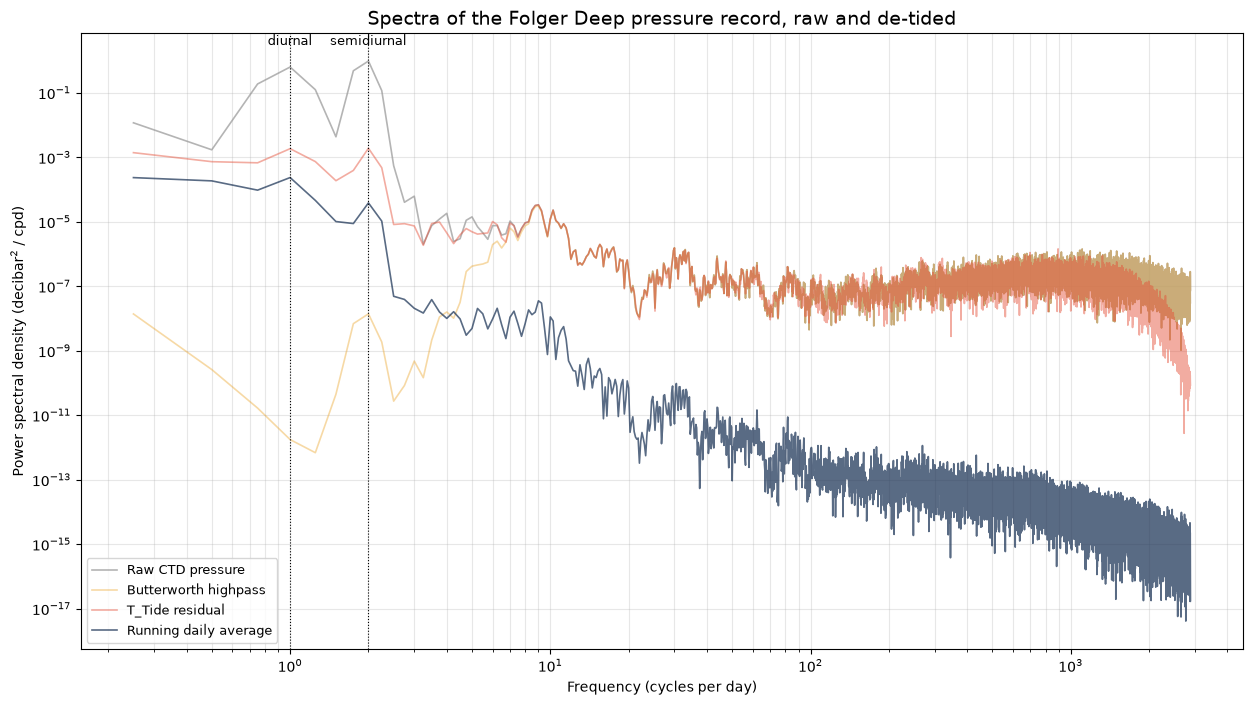

In [12]:
fs_cpd = pd.Timedelta('1D') / sample_interval        # samples per day
nperseg = int(pd.Timedelta('4D') / sample_interval)  # samples in one Welch segment

def spectrum(series):
    """Power spectral density of one column, in dbar^2 per cycle per day.

    The running average leaves NaNs at both ends of the record, so drop those
    first. The 0 cpd bin is dropped at the end so the frequency axis can be log.
    """
    values = pd.Series(series).dropna().to_numpy(dtype=float)
    freq, psd = welch(values, fs=fs_cpd, nperseg=nperseg, detrend='linear')
    return freq[1:], psd[1:]

plt.figure(figsize=(15, 8))

for name, color, label in [('raw pressure',          '#999999BB', 'Raw CTD pressure'),
                           ('highpass filtered',     '#eba22468', 'Butterworth highpass'),
                           ('residual',              '#E54D3677', 'T_Tide residual'),
                           ('daily average detided', '#1D3557BB', 'Running daily average')]:
    plt.loglog(*spectrum(df[name]), lw=1.2, color=color, label=label)

for cpd, label in [(1, 'diurnal'), (2, 'semidiurnal')]:
    plt.axvline(cpd, color='k', lw=0.8, ls=':')
    plt.text(cpd, 3, label, ha='center', fontsize=9)

plt.xlabel('Frequency (cycles per day)')
plt.ylabel(f'Power spectral density ({d.units}$^2$ / cpd)')
plt.title('Spectra of the Folger Deep pressure record, raw and de-tided', fontsize=14)
plt.legend(loc='lower left', fontsize=9)
plt.grid(True, alpha=0.3, which='both')
plt.show()